# Experiment 7: Signal Denoising using Autoencoder

## Step 1
Import the required libraries.

In [1]:
import os
import gc
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import kagglehub

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Step 2
Load the dataset, reshape the images to 1 x 28 x 28 and define a function to add noise.

In [2]:
path = kagglehub.dataset_download("shayanfazeli/heartbeat")


def find_csv(name):
    return glob.glob(os.path.join(path, "**", name), recursive=True)[0]


frames = [pd.read_csv(find_csv(n), header=None) for n in ["ptbdb_normal.csv", "ptbdb_abnormal.csv"]]
data = pd.concat(frames).sample(frac=1.0, random_state=42).values.astype(np.float32)
signals = torch.tensor(data[:, :187]).unsqueeze(1)
n_test = int(0.2 * len(signals))
Xtr, Xte = signals[:-n_test], signals[-n_test:]

noise_std = 0.1
batch_size = 256


def add_noise(x):
    return x + noise_std * torch.randn_like(x)


def make_loader(X, bs, shuffle):
    return DataLoader(TensorDataset(X), batch_size=bs, shuffle=shuffle)


print(Xtr.shape, Xte.shape)

100%|██████████| 98.8M/98.8M [01:32<00:00, 1.12MB/s]

Extracting files...


torch.Size([11642, 1, 187]) torch.Size([2910, 1, 187])


## Step 3
Define the encoder layers (convolution and pooling) and the decoder layers (upsampling and transposed convolution).

In [3]:
class SignalAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv1d(1, 32, 5, padding=2), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 5, padding=2), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 5, padding=2), nn.ReLU(),
        )
        self.dec = nn.Sequential(
            nn.Conv1d(128, 64, 5, padding=2), nn.ReLU(),
            nn.Upsample(size=93),
            nn.Conv1d(64, 32, 5, padding=2), nn.ReLU(),
            nn.Upsample(size=187),
            nn.Conv1d(32, 1, 5, padding=2),
        )

    def forward(self, x):
        return self.dec(self.enc(x))


epochs = 15
use_amp = device.type == "cuda"
model = SignalAE().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
print(f"parameters: {sum(p.numel() for p in model.parameters())}")

parameters: 103041


## Step 4
Train the autoencoder for 6 epochs with noisy images as input and clean images as target.

In [4]:
def free_memory():
    if device.type == "cuda":
        torch.cuda.empty_cache()


def is_oom(e):
    return isinstance(e, torch.cuda.OutOfMemoryError) or "out of memory" in str(e).lower()


def safe_call(fn, bs, min_bs=8):
    while True:
        try:
            return fn(bs), bs
        except RuntimeError as e:
            if not is_oom(e):
                raise
        model.zero_grad(set_to_none=True)
        gc.collect()
        free_memory()
        if bs <= min_bs:
            raise RuntimeError("out of memory even at the smallest batch size")
        bs = max(min_bs, bs // 2)
        print(f"out of memory, retrying with batch size {bs}")


def train_one_epoch(bs):
    model.train()
    tot = 0.0
    n = 0
    for (x,) in make_loader(Xtr, bs, True):
        x = x.to(device)
        opt.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, enabled=use_amp):
            out = model(add_noise(x))
        loss = F.mse_loss(out.float(), x)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        tot += loss.item() * x.numel()
        n += x.numel()
    return tot / n


for ep in range(epochs):
    train_loss, batch_size = safe_call(train_one_epoch, batch_size)
    free_memory()
    print(f"epoch {ep + 1}/{epochs} batch_size {batch_size} train_mse {train_loss:.6f}")

epoch 1/15 batch_size 256 train_mse 0.021543
epoch 2/15 batch_size 256 train_mse 0.005295
epoch 3/15 batch_size 256 train_mse 0.002732
epoch 4/15 batch_size 256 train_mse 0.002129
epoch 5/15 batch_size 256 train_mse 0.001937
epoch 6/15 batch_size 256 train_mse 0.001752
epoch 7/15 batch_size 256 train_mse 0.001665
epoch 8/15 batch_size 256 train_mse 0.001612
epoch 9/15 batch_size 256 train_mse 0.001532
epoch 10/15 batch_size 256 train_mse 0.001506
epoch 11/15 batch_size 256 train_mse 0.001469
epoch 12/15 batch_size 256 train_mse 0.001431
epoch 13/15 batch_size 256 train_mse 0.001430
epoch 14/15 batch_size 256 train_mse 0.001394
epoch 15/15 batch_size 256 train_mse 0.001375


## Step 5
Test it on noisy test images, output the error and PSNR of the noisy and denoised images and save the picture.

noisy vs clean: mse 0.009995 snr 8.86 dB
denoised vs clean: mse 0.001430 snr 17.31 dB


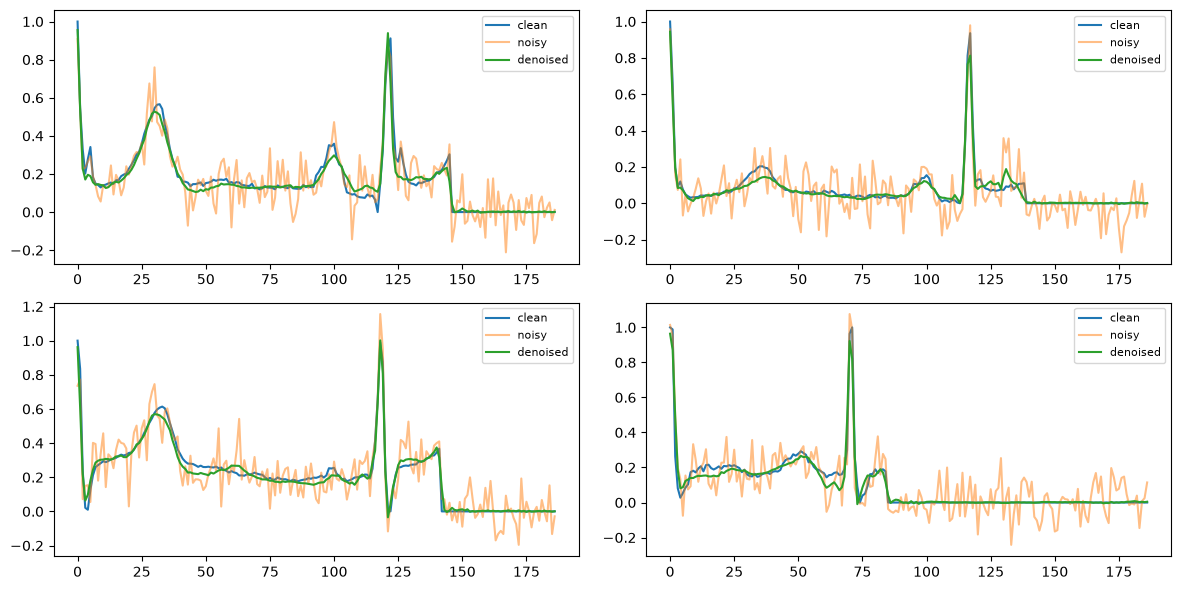

In [5]:
def test_pass(bs):
    model.eval()
    torch.manual_seed(0)
    sq_noisy = 0.0
    sq_den = 0.0
    power = 0.0
    n = 0
    with torch.no_grad():
        for i in range(0, len(Xte), bs):
            x = Xte[i:i + bs].to(device)
            nx = add_noise(x)
            with torch.autocast(device_type=device.type, enabled=use_amp):
                out = model(nx)
            sq_noisy += ((nx - x) ** 2).sum().item()
            sq_den += ((out.float() - x) ** 2).sum().item()
            power += (x ** 2).sum().item()
            n += x.numel()
    return sq_noisy, sq_den, power, n


free_memory()
(sq_noisy, sq_den, power, n), _ = safe_call(test_pass, 512)
print(f"noisy vs clean: mse {sq_noisy / n:.6f} snr {10 * np.log10(power / sq_noisy):.2f} dB")
print(f"denoised vs clean: mse {sq_den / n:.6f} snr {10 * np.log10(power / sq_den):.2f} dB")

model.eval()
torch.manual_seed(0)
with torch.no_grad():
    x = Xte[:4].to(device)
    nx = add_noise(x)
    den = model(nx).cpu()
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.plot(Xte[i, 0], label="clean", linewidth=1.5)
    ax.plot(nx[i, 0].cpu(), label="noisy", alpha=0.5)
    ax.plot(den[i, 0], label="denoised", linewidth=1.5)
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("exp07_ecg_denoising.png", dpi=100)
plt.show()